In [ ]:
import time
import pandas as pd

trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")

print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [ ]:
print(trades.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [20]:
import pandas as pd

# Convert timestamps
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Convert IST → UTC
trades["timestamp_utc"] = (
    trades["Timestamp IST"]
    - pd.Timedelta(hours=5, minutes=30)
)

trades["match_date"] = (
    trades["timestamp_utc"]
    .dt.date
)

# Sentiment dates
sentiment["date"] = pd.to_datetime(
    sentiment["date"]
)

sentiment["date"] = (
    sentiment["date"]
    .dt.date
)

In [21]:
merged = trades.merge(
    sentiment[
        ["date","classification","value"]
    ],
    left_on="match_date",
    right_on="date",
    how="left"
)

print(merged.shape)
print(
    merged["classification"]
    .isna()
    .sum()
)

(211224, 22)
0


In [22]:
merged["net_pnl"] = (
    merged["Closed PnL"]
    -
    merged["Fee"]
)

In [23]:
merged["win"] = (
    merged["net_pnl"] > 0
).astype(int)

In [24]:
merged["exposure"] = (
    merged["Size USD"]
    /
    (
        merged["Start Position"]
        .abs()
        +
        1
    )
)

In [25]:
merged["leverage_bucket"] = pd.cut(
    merged["exposure"],
    bins=[
        0,
        3,
        10,
        100000
    ],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [26]:
account_avg = (
    merged
    .groupby("Account")
    ["Size USD"]
    .transform("mean")
)

merged["position_sizing_pct"] = (
    merged["Size USD"]
    /
    account_avg
)

In [27]:
trade_df = merged.copy()

In [28]:
account_day = (
    merged
    .groupby(
        [
            "Account",
            "match_date",
            "classification"
        ]
    )
    .agg({
        "net_pnl":"sum",
        "win":"mean",
        "Size USD":"sum",
        "position_sizing_pct":"mean"
    })
    .reset_index()
)

account_day.columns = [
    "Account",
    "date",
    "sentiment",
    "daily_pnl",
    "win_rate",
    "daily_volume",
    "conviction"
]

In [56]:
account_profile = (
    merged
    .groupby("Account")
    .agg({
        "net_pnl":"sum",
        "win":"mean",
        "Size USD":"mean",
        "position_sizing_pct":"std"
    })
)
# Fill NaN values with 0.0 for accounts with only one trade (no std deviation)
account_profile["position_sizing_pct"] = account_profile["position_sizing_pct"].fillna(0.0)

In [30]:
coin_day = (
    merged
    .groupby(
        [
            "Coin",
            "match_date",
            "classification"
        ]
    )
    .agg({
        "net_pnl":"mean",
        "Size USD":"sum"
    })
    .reset_index()
)

In [31]:
#does sentiment affect trader performance?
account_day.groupby(
    "sentiment"
)[
    "daily_pnl"
].mean()

,daily_pnl
sentiment,
Extreme Fear,6796.011545
Extreme Greed,4937.942471
Fear,4373.084777
Greed,3622.764534
Neutral,3377.931522


In [32]:
#Does sentiment affect win rate?
account_day.groupby(
    "sentiment"
)[
    "win_rate"
].mean()

,win_rate
sentiment,
Extreme Fear,0.366590
Extreme Greed,0.387507
Fear,0.366216
Greed,0.350234
Neutral,0.353890


In [33]:
#Do traders bet larger in Greed?
account_day.groupby(
    "sentiment"
)[
    "conviction"
].mean()

,conviction
sentiment,
Extreme Fear,1.395126
Extreme Greed,1.059951
Fear,1.557387
Greed,1.244552
Neutral,1.131279


In [34]:
#Does extreme sentiment increase risk?

pd.crosstab(
    merged["classification"],
    merged["leverage_bucket"]
)

leverage_bucket,Low,Medium,High
classification,,,
Extreme Fear,16182,1249,3861
Extreme Greed,30361,2136,7670
Fear,45166,3317,12980
Greed,33584,2737,12320
Neutral,30005,2219,7332


In [36]:
pd.crosstab(merged["classification"], merged["leverage_bucket"], normalize='index') * 100

leverage_bucket,Low,Medium,High
classification,,,
Extreme Fear,76.000376,5.866053,18.133571
Extreme Greed,75.586925,5.317798,19.095277
Fear,73.484861,5.396743,21.118396
Greed,69.044633,5.626940,25.328427
Neutral,75.854485,5.609768,18.535747


In [37]:
from scipy.stats import f_oneway, kruskal

groups = [g["daily_pnl"].values for _, g in account_day.groupby("sentiment")]
f_oneway(*groups)      # if roughly normal
kruskal(*groups)       # safer, PnL is usually skewed/fat-tailed

KruskalResult(statistic=np.float64(20.761014629373708), pvalue=np.float64(0.00035315436306277196))

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = account_profile[["net_pnl", "win", "position_sizing_pct"]]
scaled = StandardScaler().fit_transform(features)
account_profile["cluster"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(scaled)

In [59]:
from sklearn.metrics import silhouette_score
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled)
    print(k, silhouette_score(scaled, km.labels_))

2 0.17103958231794658
3 0.20255647046868813
4 0.2150144332272151
5 0.23019875640230814
6 0.2418970384575623


In [57]:
# Add sentiment-specific behavior features to account_profile

# Drop existing sentiment-related columns if they exist to prevent ValueError on re-run
columns_to_drop = ["win_rate_fear", "win_rate_greed", "fear_greed_win_gap"]
account_profile = account_profile.drop(columns=[col for col in columns_to_drop if col in account_profile.columns])

fear_days = account_day[account_day["sentiment"].isin(["Fear", "Extreme Fear"])]
greed_days = account_day[account_day["sentiment"].isin(["Greed", "Extreme Greed"])]

fear_stats = fear_days.groupby("Account")["win_rate"].mean().rename("win_rate_fear")
greed_stats = greed_days.groupby("Account")["win_rate"].mean().rename("win_rate_greed")

account_profile = account_profile.join(fear_stats).join(greed_stats)
account_profile["fear_greed_win_gap"] = account_profile["win_rate_fear"] - account_profile["win_rate_greed"]
account_profile[["win_rate_fear","win_rate_greed","fear_greed_win_gap"]] = \
    account_profile[["win_rate_fear","win_rate_greed","fear_greed_win_gap"]].fillna(0)

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = account_profile[["net_pnl", "win", "position_sizing_pct", "win_rate_fear", "win_rate_greed", "fear_greed_win_gap"]].dropna()
scaled = StandardScaler().fit_transform(features)
account_profile["cluster"] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(scaled)

In [60]:
cluster_summary = account_profile.groupby("cluster")[
    ["net_pnl", "win_rate_fear", "win_rate_greed", "fear_greed_win_gap", "position_sizing_pct"]
].mean()
cluster_summary["count"] = account_profile.groupby("cluster").size()
cluster_summary

,net_pnl,win_rate_fear,win_rate_greed,fear_greed_win_gap,position_sizing_pct,count
cluster,,,,,,
0,6.540336e+05,0.632565,0.715472,-0.082906,3.454469,2
1,2.098870e+05,0.283464,0.240449,0.043015,4.130470,8
2,1.772144e+05,0.441551,0.345663,0.068204,2.499308,15
3,1.860106e+06,0.384425,0.250853,0.133572,2.899931,2
4,1.371020e+05,0.174833,0.502056,-0.327223,2.538020,5


Text(0.5, 1.0, 'Trader Archetypes: Fear vs Greed Performance')

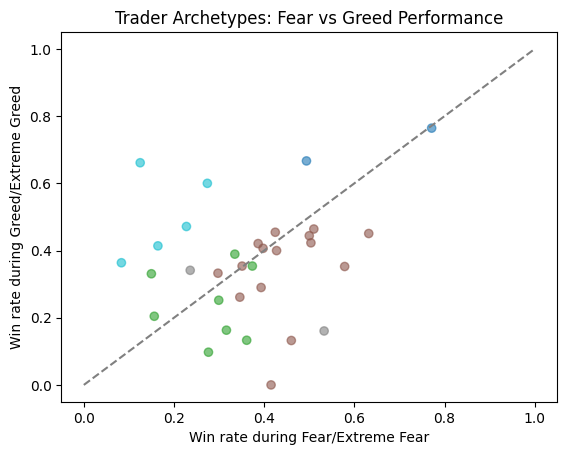

In [61]:
import matplotlib.pyplot as plt
plt.scatter(account_profile["win_rate_fear"], account_profile["win_rate_greed"],
            c=account_profile["cluster"], cmap="tab10", alpha=0.6)
plt.xlabel("Win rate during Fear/Extreme Fear")
plt.ylabel("Win rate during Greed/Extreme Greed")
plt.plot([0,1],[0,1], linestyle="--", color="gray")  # diagonal = no regime bias
plt.title("Trader Archetypes: Fear vs Greed Performance")

In [53]:
sentiment_lagged = sentiment.copy()
sentiment_lagged["date"] = sentiment_lagged["date"] + pd.Timedelta(days=1)
sentiment_lagged = sentiment_lagged.rename(columns={"classification":"sentiment_lag1"})

merged_lag = account_day.merge(sentiment_lagged[["date","sentiment_lag1"]], on="date")
merged_lag.groupby("sentiment_lag1")["daily_pnl"].mean()

,daily_pnl
sentiment_lag1,
Extreme Fear,6621.042103
Extreme Greed,4897.301922
Fear,4772.331585
Greed,3750.201836
Neutral,2523.443173


In [63]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(pd.crosstab(merged["classification"], merged["leverage_bucket"]))
print(chi2, p)

917.2225375929766 1.0881369399739277e-192


In [62]:
account_profile["position_sizing_pct"].describe()

,position_sizing_pct
count,32.000000
mean,2.997884
std,1.008964
min,1.302574
25%,2.253392
50%,3.062363
75%,3.799264
max,5.666198


In [64]:
for lag in [1, 3, 7]:
    sl = sentiment.copy()
    sl["date"] = sl["date"] + pd.Timedelta(days=lag)
    sl = sl.rename(columns={"classification": f"sentiment_lag{lag}"})
    m = account_day.merge(sl[["date", f"sentiment_lag{lag}"]], on="date")
    print(f"--- lag {lag} ---")
    print(m.groupby(f"sentiment_lag{lag}")["daily_pnl"].mean())

--- lag 1 ---
sentiment_lag1
Extreme Fear     6621.042103
Extreme Greed    4897.301922
Fear             4772.331585
Greed            3750.201836
Neutral          2523.443173
Name: daily_pnl, dtype: float64
--- lag 3 ---
sentiment_lag3
Extreme Fear     11253.767625
Extreme Greed     6594.305664
Fear              2480.132260
Greed             3098.601075
Neutral           2975.881774
Name: daily_pnl, dtype: float64
--- lag 7 ---
sentiment_lag7
Extreme Fear     5814.611250
Extreme Greed    6027.354155
Fear             2168.403354
Greed            3244.656080
Neutral          6807.606852
Name: daily_pnl, dtype: float64


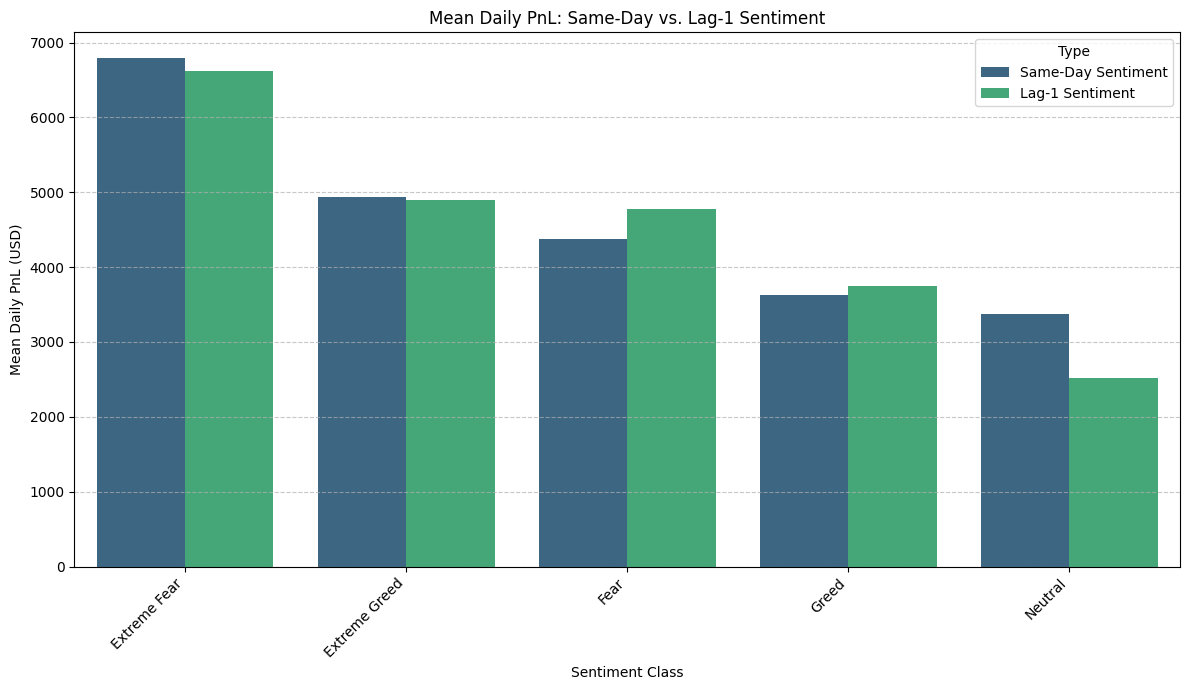

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get same-day daily_pnl means
same_day_pnl = account_day.groupby("sentiment")["daily_pnl"].mean().reset_index()
same_day_pnl["Type"] = "Same-Day Sentiment"
same_day_pnl = same_day_pnl.rename(columns={
    "sentiment": "Sentiment Class",
    "daily_pnl": "Mean Daily PnL"
})

# Get lag-1 daily_pnl means from merged_lag (already calculated in previous cell)
# The 'm' variable from the loop in _gstAJYBQ9Mu holds the merged data for the last lag (lag 7).
# We need to re-run the lag 1 part to get the specific 'merged_lag' for lag 1.
# Or, more directly, use the `merged_lag` DataFrame from cell b5hf75XXQGQr.
lag1_pnl = merged_lag.groupby("sentiment_lag1")["daily_pnl"].mean().reset_index()
lag1_pnl["Type"] = "Lag-1 Sentiment"
lag1_pnl = lag1_pnl.rename(columns={
    "sentiment_lag1": "Sentiment Class",
    "daily_pnl": "Mean Daily PnL"
})

# Combine the dataframes
comparison_df = pd.concat([same_day_pnl, lag1_pnl])

# Plotting
fig = plt.figure(figsize=(12, 7))
sns.barplot(x="Sentiment Class", y="Mean Daily PnL", hue="Type", data=comparison_df, palette="viridis")
plt.title("Mean Daily PnL: Same-Day vs. Lag-1 Sentiment")
plt.ylabel("Mean Daily PnL (USD)")
plt.xlabel("Sentiment Class")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

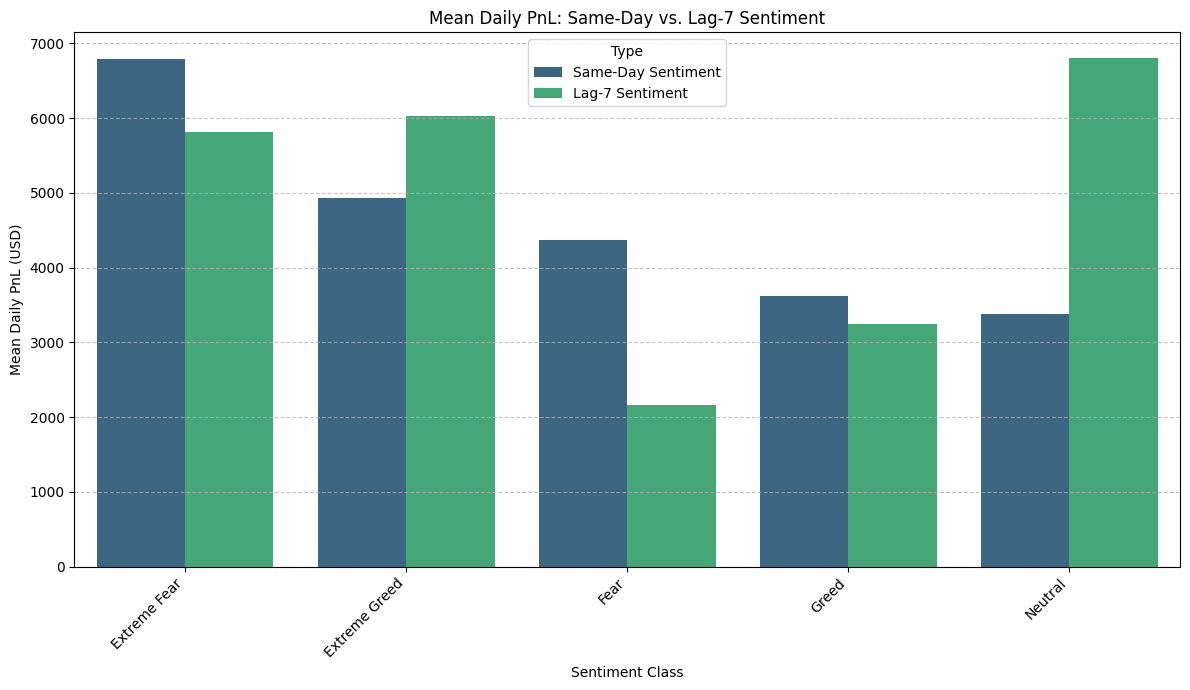

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get same-day daily_pnl means
same_day_pnl = account_day.groupby("sentiment")["daily_pnl"].mean().reset_index()
same_day_pnl["Type"] = "Same-Day Sentiment"
same_day_pnl = same_day_pnl.rename(columns={
    "sentiment": "Sentiment Class",
    "daily_pnl": "Mean Daily PnL"
})

# Generate lag-7 daily_pnl means
sl_lag7 = sentiment.copy()
sl_lag7["date"] = sl_lag7["date"] + pd.Timedelta(days=7)
sl_lag7 = sl_lag7.rename(columns={"classification": "sentiment_lag7"})
m_lag7 = account_day.merge(sl_lag7[["date", "sentiment_lag7"]], on="date")

lag7_pnl = m_lag7.groupby("sentiment_lag7")["daily_pnl"].mean().reset_index()
lag7_pnl["Type"] = "Lag-7 Sentiment"
lag7_pnl = lag7_pnl.rename(columns={
    "sentiment_lag7": "Sentiment Class",
    "daily_pnl": "Mean Daily PnL"
})

# Combine the dataframes
comparison_df_lag7 = pd.concat([same_day_pnl, lag7_pnl])

# Plotting
fig = plt.figure(figsize=(12, 7))
sns.barplot(x="Sentiment Class", y="Mean Daily PnL", hue="Type", data=comparison_df_lag7, palette="viridis")
plt.title("Mean Daily PnL: Same-Day vs. Lag-7 Sentiment")
plt.ylabel("Mean Daily PnL (USD)")
plt.xlabel("Sentiment Class")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [67]:
for lag in [1, 3, 7]:
    sl = sentiment.copy()
    sl["date"] = sl["date"] + pd.Timedelta(days=lag)
    sl = sl.rename(columns={"classification": f"sentiment_lag{lag}"})
    m = account_day.merge(sl[["date", f"sentiment_lag{lag}"]], on="date")
    print(f"--- lag {lag} ---")
    print(m.groupby(f"sentiment_lag{lag}")["daily_pnl"].agg(["mean","count","std"]))

--- lag 1 ---
                       mean  count           std
sentiment_lag1                                  
Extreme Fear    6621.042103    151  32577.092462
Extreme Greed   4897.301922    540  25271.517573
Fear            4772.331585    648  33828.502578
Greed           3750.201836    638  24782.086321
Neutral         2523.443173    365  23913.506769
--- lag 3 ---
                        mean  count           std
sentiment_lag3                                   
Extreme Fear    11253.767625    161  51583.356648
Extreme Greed    6594.305664    551  33468.459407
Fear             2480.132260    645  25162.845408
Greed            3098.601075    629  21832.702120
Neutral          2975.881774    355  15257.212329
--- lag 7 ---
                       mean  count           std
sentiment_lag7                                  
Extreme Fear    5814.611250    154  27462.373223
Extreme Greed   6027.354155    579  32213.907994
Fear            2168.403354    662  23851.171776
Greed           3244

In [68]:
for lag in [1, 3, 7]:
    sl = sentiment.copy()
    sl["date"] = sl["date"] + pd.Timedelta(days=lag)
    sl = sl.rename(columns={"classification": f"sentiment_lag{lag}"})
    m = account_day.merge(sl[["date", f"sentiment_lag{lag}"]], on="date")
    print(f"--- lag {lag} ---")
    print(m.groupby(f"sentiment_lag{lag}")["daily_pnl"].agg(["mean","median","count","std"]))

--- lag 1 ---
                       mean      median  count           std
sentiment_lag1                                              
Extreme Fear    6621.042103  261.904608    151  32577.092462
Extreme Greed   4897.301922  354.406082    540  25271.517573
Fear            4772.331585   95.104272    648  33828.502578
Greed           3750.201836  176.264939    638  24782.086321
Neutral         2523.443173  179.143740    365  23913.506769
--- lag 3 ---
                        mean      median  count           std
sentiment_lag3                                               
Extreme Fear    11253.767625  210.995512    161  51583.356648
Extreme Greed    6594.305664  390.164634    551  33468.459407
Fear             2480.132260  130.525422    645  25162.845408
Greed            3098.601075  151.974480    629  21832.702120
Neutral          2975.881774  130.549949    355  15257.212329
--- lag 7 ---
                       mean      median  count           std
sentiment_lag7                      

/tmp/ipykernel_1535/4293992908.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment', y='daily_pnl', data=avg_daily_pnl_by_sentiment, palette='coolwarm')


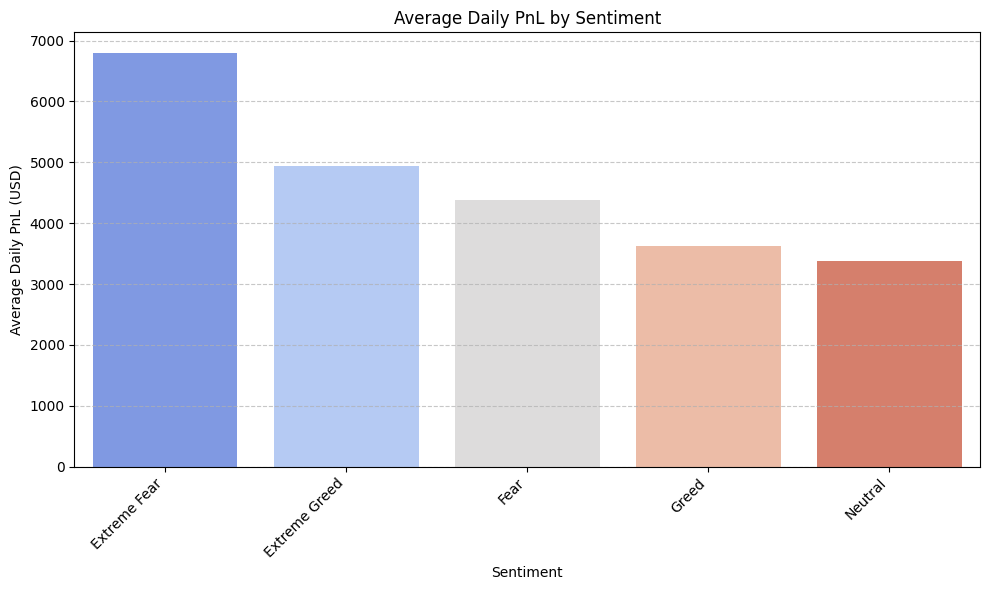

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean daily PnL by sentiment
avg_daily_pnl_by_sentiment = account_day.groupby('sentiment')['daily_pnl'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='sentiment', y='daily_pnl', data=avg_daily_pnl_by_sentiment, palette='coolwarm')
plt.title('Average Daily PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Daily PnL (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1535/417953941.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment', y='win_rate', data=avg_win_rate_by_sentiment, palette='coolwarm')


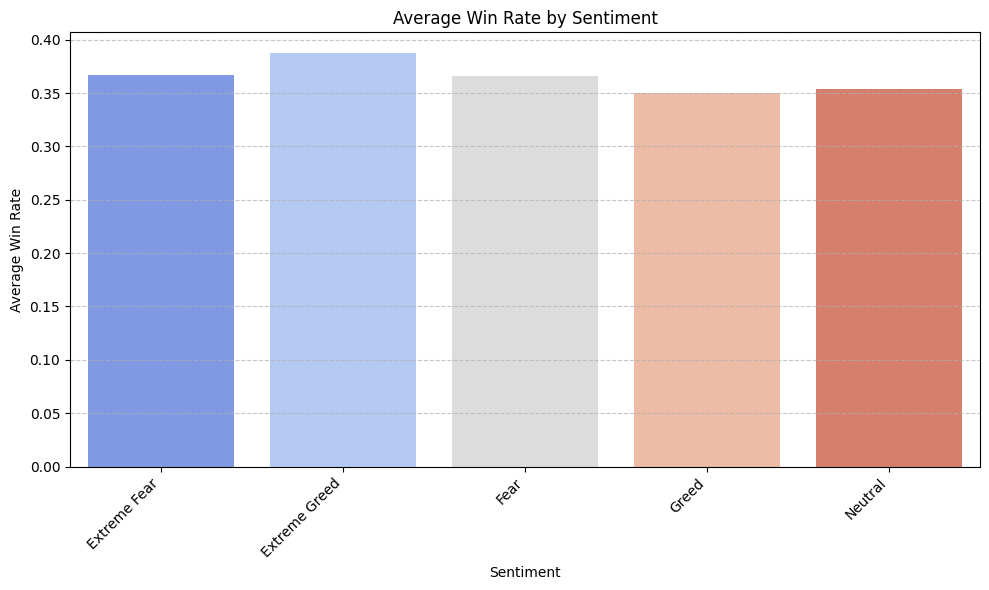

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean win rate by sentiment
avg_win_rate_by_sentiment = account_day.groupby('sentiment')['win_rate'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='sentiment', y='win_rate', data=avg_win_rate_by_sentiment, palette='coolwarm')
plt.title('Average Win Rate by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Win Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

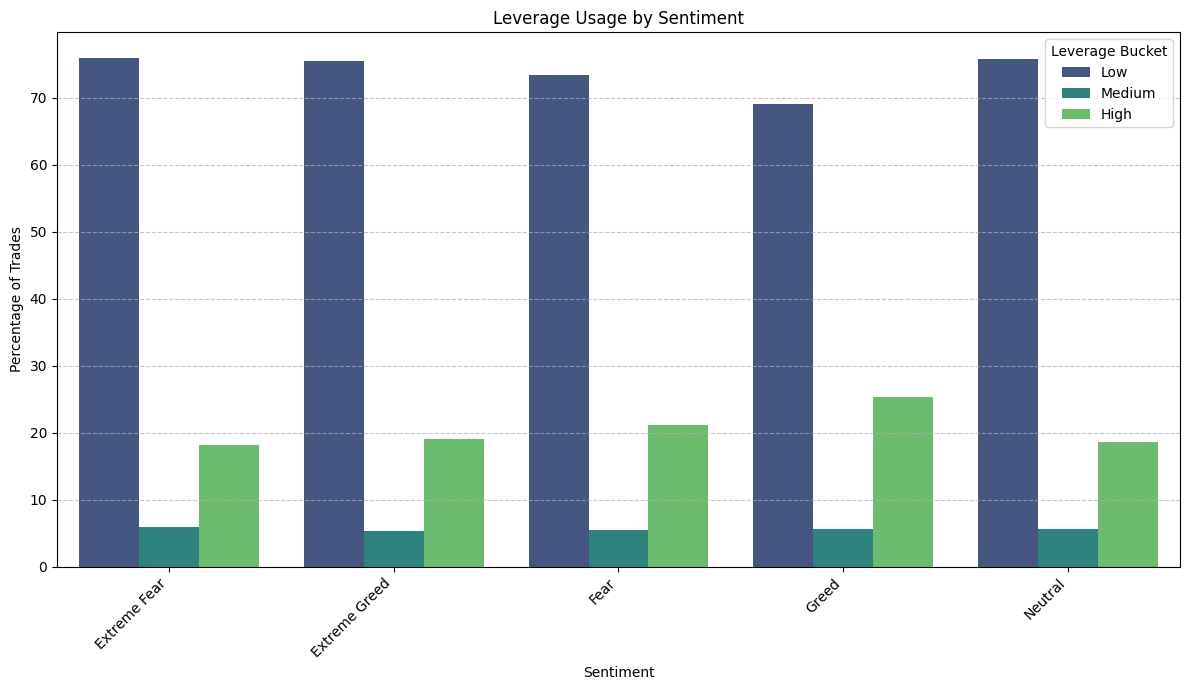

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage distribution of leverage_bucket by sentiment
leverage_by_sentiment = pd.crosstab(
    merged['classification'],
    merged['leverage_bucket'],
    normalize='index'
) * 100

# Reset index to make 'classification' a column for plotting
leverage_by_sentiment = leverage_by_sentiment.reset_index()

# Melt the DataFrame to long format for easier plotting with seaborn
leverage_by_sentiment_melted = leverage_by_sentiment.melt(
    id_vars='classification',
    var_name='Leverage Bucket',
    value_name='Percentage'
)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    x='classification',
    y='Percentage',
    hue='Leverage Bucket',
    data=leverage_by_sentiment_melted,
    palette='viridis'
)
plt.title('Leverage Usage by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Percentage of Trades')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Leverage Bucket')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

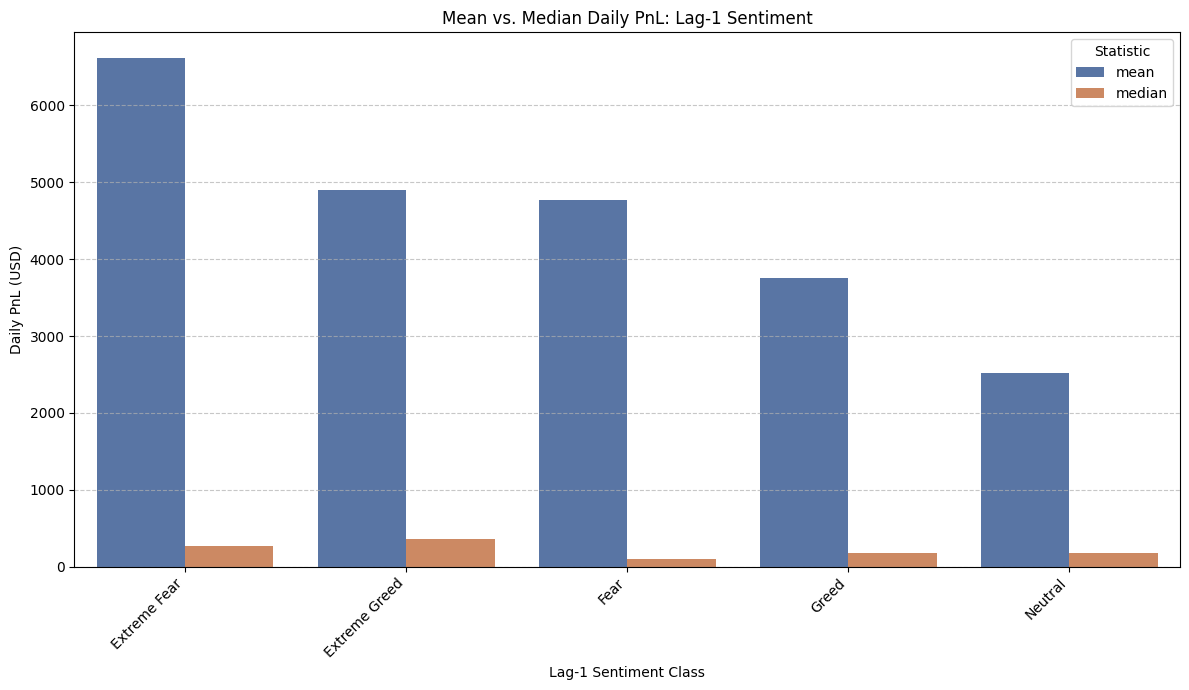

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean and median daily PnL by sentiment_lag1
lag1_pnl_stats = merged_lag.groupby('sentiment_lag1')['daily_pnl'].agg(['mean', 'median']).reset_index()

# Melt the DataFrame to long format for easier plotting
lag1_pnl_stats_melted = lag1_pnl_stats.melt(
    id_vars='sentiment_lag1',
    var_name='Statistic',
    value_name='Daily PnL'
)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    x='sentiment_lag1',
    y='Daily PnL',
    hue='Statistic',
    data=lag1_pnl_stats_melted,
    palette='deep'
)
plt.title('Mean vs. Median Daily PnL: Lag-1 Sentiment')
plt.xlabel('Lag-1 Sentiment Class')
plt.ylabel('Daily PnL (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Statistic')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()